# 傾向スコアマッチング と 差分の差分法 — Colab ハンズオン

経営情報各論BⅠ/EⅠ第14回 / 因果推論 第2回 講義補助ノートブック

このノートブックは講義のサンプルコードを上から順に実行できる形にまとめたものです。
前半で **傾向スコアマッチング (PSM)**、後半で **差分の差分法 (DID)** を、
シミュレーションデータで手を動かしながら学びます。最後に **練習問題4問** があります。

> **使い方:** 上のメニューから「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。
> 追加インストールは不要です(numpy / pandas / scikit-learn / statsmodels / matplotlib はColabに最初から入っています)。

---

### 目次
**Part 1 — 傾向スコアマッチング (PSM)**
1. データを作る ―「やる気」が交絡する世界
2. 素朴な差を見る(罠)
3. 傾向スコアを推定する
4. 最近傍マッチング
5. バランス確認(SMD)
6. ATT の推定

**Part 2 — 差分の差分法 (DID)**
7. パネルデータを作る ― ある県だけの最低賃金引上げ
8. 2×2 の手計算
9. 交互作用つき回帰で DID
10. 平行トレンドを図で見る

**練習問題(Q1〜Q4)**


# Part 1 — 傾向スコアマッチング (PSM)

## 0. 準備

In [9]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 42.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=61a147da2f5c8e82c5dd33055385b4886a7fadac72bd98f7d22fd9b69fea3617
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.formula.api as smf
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False
rng = np.random.default_rng(42)
print("準備OK")

準備OK


## 1. データを作る ―「やる気」が交絡する世界

「有料のオンライン講座を受けると試験の点数は上がるか?」を題材に、1000人をシミュレートします。
鍵は **やる気 (motivation)** で、これが **受講するか (X)** と **点数 (Y)** の両方に効く交絡因子です。
さらに **成績 (gpa)** もやる気と相関する共変量として加えます。真の因果効果は **+5点** と仕込みます。


In [11]:
n = 1000
motivation = rng.uniform(0, 1, n)                         # 交絡因子: やる気
gpa = np.clip(rng.normal(2.5 + 1.2*motivation, 0.4), 0, 4)  # 成績(やる気と相関)

p_take = 0.2 + 0.6 * motivation                           # やる気が高いほど受講しやすい
X = (rng.uniform(0, 1, n) < p_take).astype(int)

true_effect = 5
Y = 50 + 25*motivation + 4*gpa + true_effect*X + rng.normal(0, 5, n)

df = pd.DataFrame(dict(motivation=motivation, gpa=gpa, X=X, Y=Y))
print(df.head())
print(f"\n受講した学生: {df.X.sum()}人 / 全{n}人  (真の効果 = +{true_effect}点)")

   motivation       gpa  X          Y
0    0.773956  3.131870  1  88.012197
1    0.438878  3.396397  1  87.557786
2    0.858598  3.544162  1  92.753934
3    0.697368  3.223723  1  88.959239
4    0.094177  2.570540  0  68.482944

受講した学生: 519人 / 全1000人  (真の効果 = +5点)


### 受講群と非受講群で「やる気」はどう違う?
受講した学生(オレンジ)の方がやる気の分布が右に寄っています。**両群はそもそも別の集団** です。


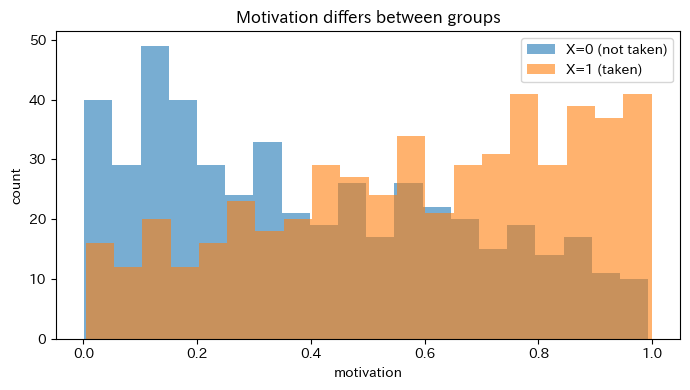

In [12]:
plt.figure(figsize=(7,4))
plt.hist(df[df.X==0].motivation, bins=20, alpha=0.6, label="X=0 (not taken)")
plt.hist(df[df.X==1].motivation, bins=20, alpha=0.6, label="X=1 (taken)")
plt.xlabel("motivation"); plt.ylabel("count")
plt.title("Motivation differs between groups"); plt.legend()
plt.tight_layout(); plt.show()

## 2. 素朴な差を見る(罠)
まず単純に「受講した人の平均点 − しなかった人の平均点」を計算します。


In [13]:
naive = df[df.X==1].Y.mean() - df[df.X==0].Y.mean()
print(f"素朴な差 : {naive:.1f}  ← 真値+5より大きい(交絡のせい)")

素朴な差 : 10.6  ← 真値+5より大きい(交絡のせい)


真値+5より大きく出るはずです。受講群はやる気・成績が高く、その分の点差が紛れ込むためです。


## 3. 傾向スコアを推定する
傾向スコア **e(x) = P(X=1 | 共変量)** を、やる気と成績からロジスティック回帰で予測します。
多次元の共変量を「受講しやすさ」という1つのスコアに要約するのがポイントです。


   motivation       gpa  X        ps
0    0.773956  3.131870  1  0.684966
1    0.438878  3.396397  1  0.466976
2    0.858598  3.544162  1  0.712861
3    0.697368  3.223723  1  0.637048
4    0.094177  2.570540  0  0.300458


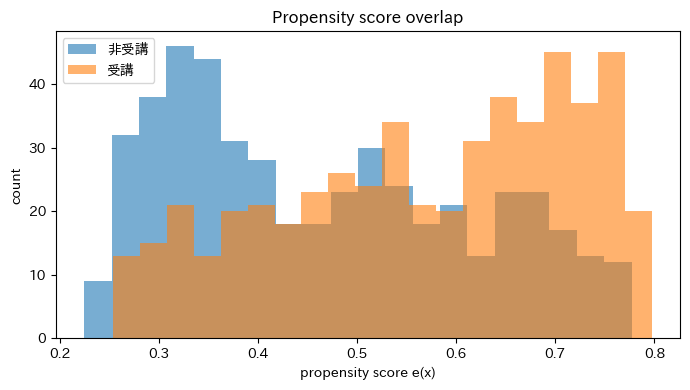

In [14]:
cov = ["motivation", "gpa"]
df["ps"] = LogisticRegression().fit(df[cov], df.X).predict_proba(df[cov])[:, 1]
print(df[["motivation","gpa","X","ps"]].head())

# 傾向スコアの分布を群別に見る(重なり=共通サポートがあるか)
plt.figure(figsize=(7,4))
plt.hist(df[df.X==0].ps, bins=20, alpha=0.6, label="非受講")
plt.hist(df[df.X==1].ps, bins=20, alpha=0.6, label="受講")
plt.xlabel("propensity score e(x)"); plt.ylabel("count")
plt.title("Propensity score overlap"); plt.legend()
plt.tight_layout(); plt.show()

## 4. 最近傍マッチング
処置群(受講)の各人に、傾向スコアが最も近い対照群(非受講)を1人ずつ対応づけます。
専用ライブラリは不要で、scikit-learn の `NearestNeighbors` で実装できます。


In [15]:
treated = df[df.X==1].copy()
control = df[df.X==0].copy()

nn = NearestNeighbors(n_neighbors=1).fit(control[["ps"]])
_, idx = nn.kneighbors(treated[["ps"]])
matched_control = control.iloc[idx.ravel()]

print(f"処置群: {len(treated)}人")
print(f"マッチした対照群: {len(matched_control)}人(重複採用あり)")

処置群: 519人
マッチした対照群: 519人(重複採用あり)


## 5. バランス確認(SMD)
マッチして終わりではありません。共変量の **標準化平均差 (SMD)** がマッチ後に小さく
(目安0.1未満)なったかを点検して、初めて妥当と言えます。


共変量のSMD(標準化平均差)
  motivation : マッチ前=+0.70  マッチ後=+0.00
  gpa        : マッチ前=+0.38  マッチ後=-0.00


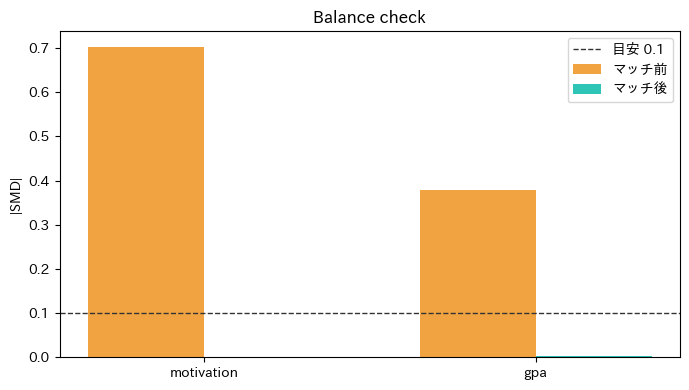

In [16]:
def smd(a, b):
    pooled = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / pooled

print("共変量のSMD(標準化平均差)")
before_list, after_list = [], []
for v in cov:
    before = smd(treated[v], control[v])
    after  = smd(treated[v], matched_control[v])
    before_list.append(abs(before)); after_list.append(abs(after))
    print(f"  {v:11s}: マッチ前={before:+.2f}  マッチ後={after:+.2f}")

# 棒グラフ
x = np.arange(len(cov)); w = 0.35
plt.figure(figsize=(7,4))
plt.bar(x-w/2, before_list, w, label="マッチ前", color="#F2A341")
plt.bar(x+w/2, after_list,  w, label="マッチ後", color="#2EC4B6")
plt.axhline(0.1, color="#333", ls="--", lw=1, label="目安 0.1")
plt.xticks(x, cov); plt.ylabel("|SMD|"); plt.title("Balance check")
plt.legend(); plt.tight_layout(); plt.show()

## 6. ATT の推定
バランスが取れたら、マッチした集団で結果Yの平均差を取ります。
これが **ATT(処置を受けた人における平均処置効果)** の推定です。


In [17]:
att = treated.Y.mean() - matched_control.Y.mean()
print(f"PSMによるATT推定 : {att:.2f}  (真値+5に近い)")
print(f"(参考)素朴な差   : {naive:.2f}  ← マッチングで交絡が減った分だけ縮む")

PSMによるATT推定 : 4.46  (真値+5に近い)
(参考)素朴な差   : 10.62  ← マッチングで交絡が減った分だけ縮む


---
# Part 2 — 差分の差分法 (DID)

## 7. パネルデータを作る ― ある県だけの最低賃金引上げ

題材を変えます。「最低賃金を上げると雇用は減るか?」を、

- **処置群:** 賃上げを実施した A県 の飲食店
- **対照群:** 実施しなかった 隣接B県 の飲食店
- **結果Y:** 店舗あたりの雇用者数

で考えます。各店舗を **処置前(post=0)** と **処置後(post=1)** の2時点で観測したパネルデータを作ります。
真の処置効果は **+2人** と仕込みます(賃上げが景気要因を除けば雇用をむしろ+2人押し上げる、という設定)。


In [18]:
n_per = 500
true_did = 2.0

# 各店舗が処置群(A県)か対照群(B県)か
treat = np.r_[np.ones(n_per), np.zeros(n_per)].astype(int)
base = 22 + 1.0*treat + rng.normal(0, 2, 2*n_per)   # A県はもともと水準がやや高い

common_trend = -3.5     # 両県に共通の時間変化(景気の落ち込み)

rows = []
for post in [0, 1]:
    Y = base + post*common_trend + post*true_did*treat + rng.normal(0, 1.0, 2*n_per)
    rows.append(pd.DataFrame(dict(treat=treat, post=post, Y=Y)))
panel = pd.concat(rows, ignore_index=True)
print(panel.head())
print(f"\n総レコード数: {len(panel)}  (店舗{2*n_per} × 2時点)")

   treat  post          Y
0      1     0  24.788205
1      1     0  27.000891
2      1     0  19.414449
3      1     0  22.863799
4      1     0  23.764011

総レコード数: 2000  (店舗1000 × 2時点)


## 8. 2×2 の手計算
処置前後の平均をクロス集計し、「変化(後−前)」を両群で出して、その差をとります。


In [19]:
tab = panel.groupby(["treat","post"]).Y.mean().unstack()
tab.index = ["B県(対照)", "A県(処置)"]
tab.columns = ["処置前", "処置後"]
tab["変化(後−前)"] = tab["処置後"] - tab["処置前"]
print(tab.round(2))

did_manual = tab.loc["A県(処置)","変化(後−前)"] - tab.loc["B県(対照)","変化(後−前)"]
print(f"\n差分の差分 (DID) = {did_manual:.2f}  (真値+2)")

          処置前    処置後  変化(後−前)
B県(対照)  21.99  18.38    -3.61
A県(処置)  23.00  21.50    -1.50

差分の差分 (DID) = 2.11  (真値+2)


両県とも景気で雇用は減りますが、**A県の減り方が小さい**。その差が賃上げの効果です。


## 9. 交互作用つき回帰で DID
DIDは回帰でも書けます。`treat`(A県か)と `post`(後か)の **交互作用 treat:post** の係数が DID 推定量です。
回帰なら標準誤差や共変量も扱えるので実務ではこちらが主流です。


In [20]:
m = smf.ols("Y ~ treat + post + treat:post", panel).fit()
print(m.params.round(3))
print(f"\nDID推定値 (treat:post) : {m.params['treat:post']:.2f}")
print(f"95%CI : [{m.conf_int().loc['treat:post'][0]:.2f}, {m.conf_int().loc['treat:post'][1]:.2f}]")
print("\n手計算の値と完全に一致するのがポイント")

Intercept     21.987
treat          1.013
post          -3.606
treat:post     2.107
dtype: float64

DID推定値 (treat:post) : 2.11
95%CI : [1.71, 2.50]

手計算の値と完全に一致するのがポイント


### 各係数の意味
- `Intercept` … B県・処置前の水準
- `treat` … A県とB県の もともとの差
- `post` … 両県に共通の時間トレンド(景気)
- `treat:post` … **これがDID = 因果効果**


## 10. 平行トレンドを図で見る
DIDの核心は **平行トレンド仮定**:「もし賃上げがなければ、A県もB県と同じ傾きで動いたはず」。
その反事実(点線)と実際のA県の差が因果効果です。


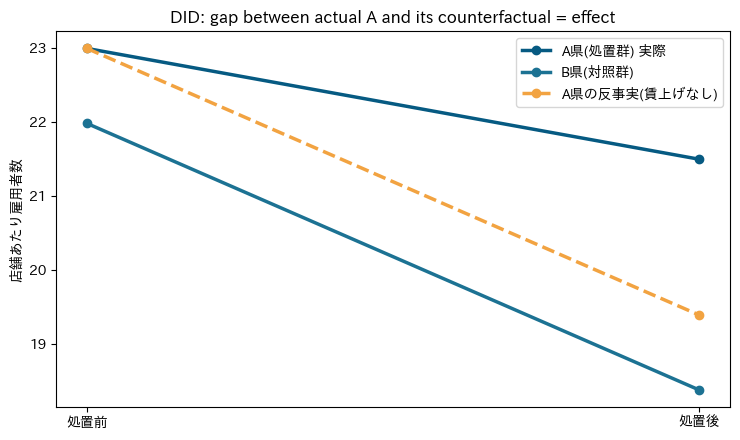

実際のA県(処置後) 21.50 − 反事実 19.39 = 2.11


In [21]:
means = panel.groupby(["treat","post"]).Y.mean().unstack()

plt.figure(figsize=(7.5,4.5))
plt.plot([0,1], means.loc[1], "o-", color="#065A82", lw=2.5, label="A県(処置群) 実際")
plt.plot([0,1], means.loc[0], "o-", color="#1C7293", lw=2.5, label="B県(対照群)")
# A県の反事実: B県と同じ傾きで動いた場合
cf_post = means.loc[1,0] + (means.loc[0,1] - means.loc[0,0])
plt.plot([0,1], [means.loc[1,0], cf_post], "o--", color="#F2A341", lw=2.5,
         label="A県の反事実(賃上げなし)")
plt.xticks([0,1], ["処置前","処置後"]); plt.ylabel("店舗あたり雇用者数")
plt.title("DID: gap between actual A and its counterfactual = effect")
plt.legend(); plt.tight_layout(); plt.show()

print(f"実際のA県(処置後) {means.loc[1,1]:.2f} − 反事実 {cf_post:.2f} = {means.loc[1,1]-cf_post:.2f}")

### Part 1・2 のまとめ

| 手法 | 必要な状況 | 打ち消せる交絡 |
|---|---|---|
| 傾向スコアマッチング (PSM) | 観測した交絡が多次元 | 観測した交絡のみ |
| 差分の差分法 (DID) | 前後×2群のパネル | 時間で一定の未観測交絡 |

- **PSM** は「受講しやすさ」が同じ人どうしをペアにして観測交絡を調整。未観測交絡には無力。
- **DID** は前後の変化を2群で比べ、時間で一定の未観測交絡まで打ち消す。平行トレンドが命。


---
# 練習問題

ここからは手を動かす番です。各問の `# TODO` を埋めて実行し、問いに答えてください。
模範解答は別ノートブック `psm_did_lecture_solutions.ipynb` にあります。


## 0. 練習用の共通関数
パラメータを変えてデータを作り直せるよう関数化しておきます(以降の問題で使います)。


In [ ]:
def make_psm_data(true_effect=5, n=400, seed=1):
    """やる気と成績が交絡する世界(PSM用)。強い選択で高スコア帯に対照群が少ない。"""
    r = np.random.default_rng(seed)
    motivation = r.uniform(0, 1, n)
    gpa = np.clip(r.normal(2.5 + 1.2*motivation, 0.4), 0, 4)
    p_take = 1 / (1 + np.exp(-(-2.5 + 6*motivation)))
    X = (r.uniform(0,1,n) < p_take).astype(int)
    Y = 50 + 25*motivation + 4*gpa + true_effect*X + r.normal(0,5,n)
    return pd.DataFrame(dict(motivation=motivation, gpa=gpa, X=X, Y=Y))

def make_did_data(true_effect=2.0, trend_gap=0.0, n_per=400, seed=3):
    """DID用パネル。trend_gap>0 で平行トレンド仮定が破れる。"""
    r = np.random.default_rng(seed)
    treat = np.r_[np.ones(n_per), np.zeros(n_per)].astype(int)
    base  = 22 + 2*treat + r.normal(0, 2, 2*n_per)
    rows = []
    for post in [0, 1]:
        Y = base + post*(-3.5) + post*trend_gap*treat + post*true_effect*treat + r.normal(0,1.5,2*n_per)
        rows.append(pd.DataFrame(dict(treat=treat, post=post, Y=Y)))
    return pd.concat(rows, ignore_index=True)

print("make_psm_data() と make_did_data() を定義しました")

## Q1. キャリパー(caliper)を変える

> 傾向スコアマッチングでは「スコア差がこの値より大きいペアは採用しない」上限を **キャリパー** と呼びます。
> 慣例として、キャリパーは **ロジットpsの標準偏差(SD)の何倍か** で指定します。
> キャリパーを **きつく(小さく)** すると、ATT推定値とマッチできたサンプル数はどう変わる?
> いくつかの値で試して、トレードオフを説明してください。


In [ ]:
df_q1 = make_psm_data()
cov = ["motivation", "gpa"]
df_q1["ps"] = LogisticRegression().fit(df_q1[cov], df_q1.X).predict_proba(df_q1[cov])[:, 1]
df_q1["logit_ps"] = np.log(df_q1.ps / (1 - df_q1.ps))
SD = df_q1.logit_ps.std()

def match_att(df, caliper_mult=None):
    """caliper_mult: ロジットpsのSDの何倍を上限にするか。None なら制限なし。"""
    treated = df[df.X==1].copy(); control = df[df.X==0].copy()
    nn = NearestNeighbors(n_neighbors=1).fit(control[["logit_ps"]])
    dist, idx = nn.kneighbors(treated[["logit_ps"]])
    dist, idx = dist.ravel(), idx.ravel()
    keep = np.ones(len(treated), dtype=bool)
    if caliper_mult is not None:
        keep = dist <= caliper_mult * SD
    att = treated[keep].Y.mean() - control.iloc[idx[keep]].Y.mean()
    return att, int(keep.sum()), len(treated)

# Q1-TODO: 各 caliper_mult で match_att を呼び、ATT・マッチ数を表にまとめよう
caliper_mults = [None, 0.5, 0.2, 0.1, 0.05]
rows = []
for cap in caliper_mults:
    # TODO: att, n_matched, n_total = match_att(df_q1, caliper_mult=cap)
    # TODO: rows.append({"caliper": "なし" if cap is None else f"{cap}×SD",
    #                    "ATT": round(att,2), "マッチ数": n_matched, "採用率": f"{n_matched/n_total*100:.0f}%"})
    pass
# TODO: print(pd.DataFrame(rows))


**答えを書く欄(Q1):** キャリパーをきつくすると ATT とマッチ数はどう動いた? なぜ?

→

## Q2. 隠れた交絡(入れ忘れ)

> 傾向スコアは「モデルに入れた共変量」しか調整できません。
> 真の交絡である **やる気 (motivation)** をスコア推定から **わざと外し**、`gpa` だけでマッチすると、
> ATTは真値(+5)からどれだけずれる? 「やる気も入れた場合」と比較してください。


In [ ]:
df_q2 = make_psm_data(true_effect=5, seed=2)

def att_with_covariates(df, cov_list):
    d = df.copy()
    d["ps"] = LogisticRegression().fit(d[cov_list], d.X).predict_proba(d[cov_list])[:, 1]
    treated, control = d[d.X==1], d[d.X==0]
    nn = NearestNeighbors(n_neighbors=1).fit(control[["ps"]])
    _, idx = nn.kneighbors(treated[["ps"]])
    return treated.Y.mean() - control.iloc[idx.ravel()].Y.mean()

# Q2-TODO: (a)gpaだけ と (b)gpa+motivation の2通りでATTを計算し、真値5と比べよう
# naive = df_q2[df_q2.X==1].Y.mean() - df_q2[df_q2.X==0].Y.mean()
# att_missing = att_with_covariates(df_q2, ["gpa"])
# att_full    = att_with_covariates(df_q2, ["gpa", "motivation"])
# TODO: print で3つ(naive, missing, full)を真値5と並べて表示


**答えを書く欄(Q2):** 入れ忘れたときのATTは真値からどれだけずれた? これは何を意味する?

→

## Q3. 平行トレンド仮定が破れると?

> DIDは「処置がなければ両群は同じ傾きで動いたはず」という平行トレンド仮定に依存します。
> `make_did_data` の `trend_gap` は「処置群が対照群より余分に持つ時間トレンド」です。
> これを変えて、DID推定が真の効果(+2)からどれだけずれるかを確かめてください。


In [ ]:
def did_estimate(panel):
    return smf.ols("Y ~ treat + post + treat:post", panel).fit().params["treat:post"]

# Q3-TODO: trend_gap を 0.0, 1.0, 2.0 と変えてDID推定を比較しよう
# for gap in [0.0, 1.0, 2.0]:
#     panel = make_did_data(true_effect=2.0, trend_gap=gap)
#     est = did_estimate(panel)
#     print(f"trend_gap={gap}: DID推定={est:.2f} (真値2.0)")


**答えを書く欄(Q3):** trend_gap が大きいほどDIDはどちらにずれた? なぜか、平行トレンドの図で説明しよう。

→

## Q4. 共変量つきDID

> DIDは回帰なので共変量を加えられます。店舗規模 `size`(Yに影響する)を加えると、
> DID係数とその **標準誤差** はどう変わる? 共変量ありとなしで比べてください。


In [ ]:
def make_did_with_cov(true_effect=2.0, n_per=400, seed=4):
    r = np.random.default_rng(seed)
    treat = np.r_[np.ones(n_per), np.zeros(n_per)].astype(int)
    size  = r.normal(50, 15, 2*n_per)
    base  = 22 + 2*treat + 0.3*(size-50) + r.normal(0, 2, 2*n_per)
    rows = []
    for post in [0, 1]:
        Y = base - post*3.5 + post*true_effect*treat + r.normal(0, 1.5, 2*n_per)
        rows.append(pd.DataFrame(dict(treat=treat, post=post, size=size, Y=Y)))
    return pd.concat(rows, ignore_index=True)

panel_q4 = make_did_with_cov()

# Q4-TODO: 共変量なし/ありの2つのDID回帰を当て、treat:post の係数と標準誤差(bse)を比べよう
# m_no  = smf.ols("Y ~ treat + post + treat:post", panel_q4).fit()
# m_cov = smf.ols("Y ~ treat + post + treat:post + size", panel_q4).fit()
# TODO: print で両者の params["treat:post"] と bse["treat:post"] を比較


**答えを書く欄(Q4):** 共変量を加えると標準誤差はどうなった? 係数自体は大きく動いた?

→

---

### 解答のヒント
- 各 `# TODO` を埋め、出力を確認したら「答えを書く欄」に2〜3文で考察を記入。
- 数値だけでなく **なぜそうなるか** を、本文の図(バランス確認・平行トレンド)と結びつけて説明できると良い。
